# Модель суміші гаусіан (GMM): кластеризація країн за World Happiness Report

**Тема 10.** Підготуємо дані *World Happiness Report 2017*, дослідимо їх, стандартизуємо та застосуємо **гаусову суміш (`GaussianMixture`)** для кластеризації країн. Порівняємо отримані кластери з реальним розподілом країн за рівнем щастя.

**Навички:** попередня підготовка даних (аналіз розподілів, кореляцій, масштабування) та робота з бібліотеками аналізу даних (`pandas`, `seaborn`, `plotly`, `sklearn`).

## 1. Інсталяція та імпорт бібліотек

In [ ]:
!pip install plotly==5.20.0
!pip install "jupyterlab>=3" "ipywidgets>=7.6"

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
from scipy.stats import skew, shapiro

from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score

# У Colab карти plotly показуються інтерактивно; локально/статично — як растрове зображення
try:
    import google.colab  # noqa
except ImportError:
    pio.renderers.default = 'png'

np.random.seed(42)
%matplotlib inline

## 2. Завантаження даних

In [ ]:
!wget -O WorldHappinessReport.zip https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/blob/main/WorldHappinessReport.zip?raw=true

## 3. Розпакування даних

In [ ]:
!unzip -o WorldHappinessReport.zip

## 4. Читання даних та загальна інформація

Використовуємо звіт за **2017 рік** (саме на нього орієнтована теплова мапа в завданні).

In [5]:
import glob, os
csv_path = './2017.csv'
if not os.path.exists(csv_path):
    csv_path = [p for p in glob.glob('**/2017.csv', recursive=True)][0]

df = pd.read_csv(csv_path)
print('Розмір:', df.shape)
df.head()

Розмір: (155, 12)


,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715
3,Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716
4,Finland,5,7.469,7.527542,7.410458,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        155 non-null    str    
 1   Happiness.Rank                 155 non-null    int64  
 2   Happiness.Score                155 non-null    float64
 3   Whisker.high                   155 non-null    float64
 4   Whisker.low                    155 non-null    float64
 5   Economy..GDP.per.Capita.       155 non-null    float64
 6   Family                         155 non-null    float64
 7   Health..Life.Expectancy.       155 non-null    float64
 8   Freedom                        155 non-null    float64
 9   Generosity                     155 non-null    float64
 10  Trust..Government.Corruption.  155 non-null    float64
 11  Dystopia.Residual              155 non-null    float64
dtypes: float64(10), int64(1), str(1)
memory usage: 14.7 KB


In [7]:
df.describe()

,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000
mean,78.000000,5.354019,5.452326,5.255713,0.984718,1.188898,0.551341,0.408786,0.246883,0.123120,1.850238
std,44.888751,1.131230,1.118542,1.145030,0.420793,0.287263,0.237073,0.149997,0.134780,0.101661,0.500028
min,1.000000,2.693000,2.864884,2.521116,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.377914
25%,39.500000,4.505500,4.608172,4.374955,0.663371,1.042635,0.369866,0.303677,0.154106,0.057271,1.591291
50%,78.000000,5.279000,5.370032,5.193152,1.064578,1.253918,0.606042,0.437454,0.231538,0.089848,1.832910
75%,116.500000,6.101500,6.194600,6.006527,1.318027,1.414316,0.723008,0.516561,0.323762,0.153296,2.144654
max,155.000000,7.537000,7.622030,7.479556,1.870766,1.610574,0.949492,0.658249,0.838075,0.464308,3.117485


## 5. Розподіли числових ознак та перевірка на нормальність

Будуємо гістограми з оцінкою щільності (KDE) для всіх числових ознак. Додатково рахуємо коефіцієнт **асиметрії (skewness)** та застосовуємо тест **Шапіро–Вілка** ($p>0.05$ — не відхиляємо гіпотезу про нормальність).

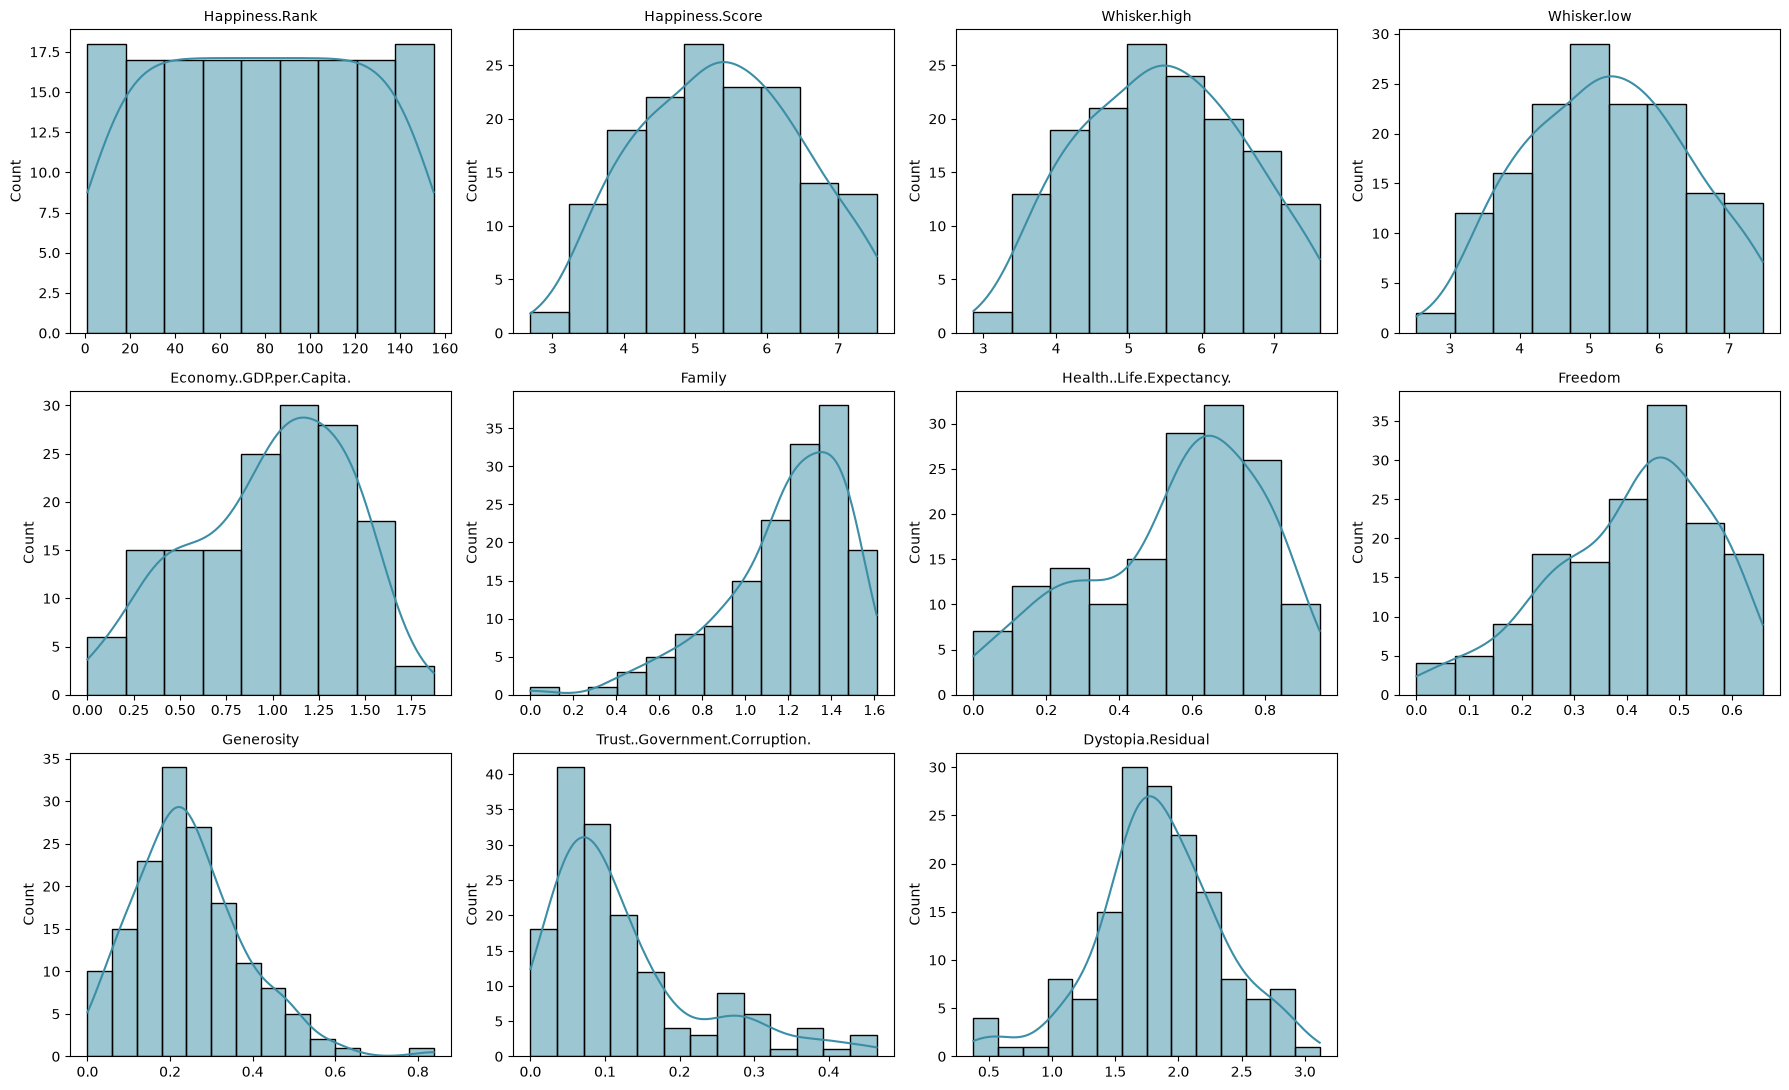

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='#3b8ea5')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
for ax in axes.ravel()[len(numeric_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

In [9]:
print(f'{"Ознака":<35}{"skew":>8}{"Shapiro p":>12}{"Нормальний?":>14}')
print('-' * 69)
for col in numeric_cols:
    sk = skew(df[col].dropna())
    p = shapiro(df[col].dropna()).pvalue
    verdict = 'так' if p > 0.05 else 'ні'
    print(f'{col:<35}{sk:>8.2f}{p:>12.4f}{verdict:>14}')

Ознака                                 skew   Shapiro p   Нормальний?
---------------------------------------------------------------------
Happiness.Rank                         0.00      0.0001            ні
Happiness.Score                        0.01      0.0522           так
Whisker.high                           0.01      0.0508           так
Whisker.low                            0.01      0.0628           так
Economy..GDP.per.Capita.              -0.39      0.0017            ні
Family                                -1.17      0.0000            ні
Health..Life.Expectancy.              -0.57      0.0000            ні
Freedom                               -0.61      0.0002            ні
Generosity                             0.89      0.0001            ні
Trust..Government.Corruption.          1.46      0.0000            ні
Dystopia.Residual                     -0.24      0.0334            ні


**Аналіз нормальності.** Більшість ознак **відхиляються від нормального розподілу** (Shapiro $p<0.05$). Помітна асиметрія: `Generosity` та `Trust..Government.Corruption.` мають виражений правий хвіст (додатна асиметрія), `Family` і `Health` — лівий. Ознаки, близькі до симетричних (`Happiness.Score`, `Freedom`), усе одно формально не проходять тест на нормальність через важкі хвости. Це типово для соціально-економічних показників і мотивує подальшу стандартизацію.

## 6. Відбір ознак та кореляційна матриця

Виходячи з розуміння домену, з-поміж усіх колонок відбираємо **шість факторів-драйверів щастя** (саме вони формують Happiness.Score у звіті), виключаючи похідні/службові (`Rank`, `Whisker.*`, `Dystopia.Residual`):

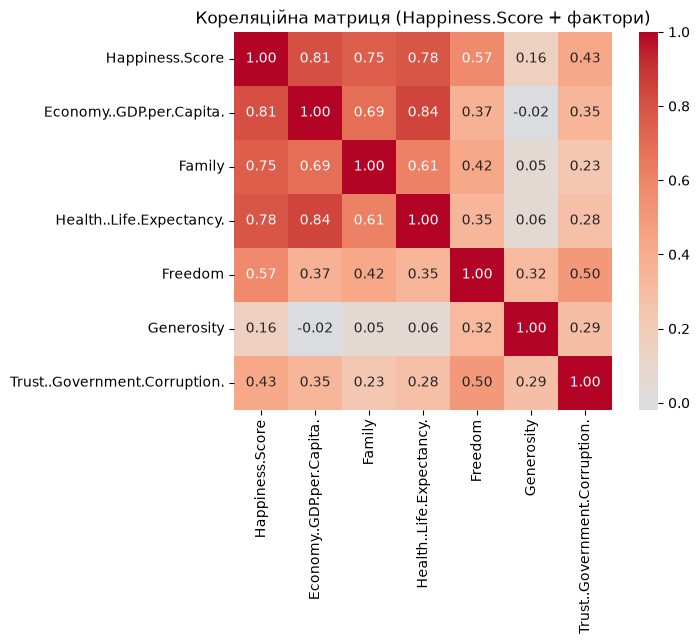

In [10]:
features = [
    'Economy..GDP.per.Capita.',
    'Family',
    'Health..Life.Expectancy.',
    'Freedom',
    'Generosity',
    'Trust..Government.Corruption.',
]

corr = df[['Happiness.Score'] + features].corr()
plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Кореляційна матриця (Happiness.Score + фактори)')
plt.tight_layout()
plt.show()

## 7. Висновок про лінійний зв'язок

- Найсильніше зі щастям корелюють **економіка (GDP per capita, r≈0.81)**, **здоров'я (r≈0.78)** та **сім'я/соціальна підтримка (r≈0.75)** — сильний прямий лінійний зв'язок.
- **Свобода** має помірний зв'язок (r≈0.5), **довіра до уряду** — слабкий (r≈0.4).
- **Generosity (щедрість)** майже не корелює зі щастям (r≈0.15) — лінійного зв'язку практично немає.
- Серед самих факторів найсильніша взаємна кореляція між **економікою та здоров'ям (r≈0.84)** — багатші країни мають вищу тривалість життя (ознака мультиколінеарності).

Отже, рівень щастя найбільше визначається матеріальним добробутом і здоров'ям.

## 8. Теплова мапа розподілу щастя за країнами

Відображаємо цільову ознаку `Happiness.Score` на карті світу (`plotly`).

/var/folders/vw/ty8wgr1n0237_dlxkbcl8rvh0000gn/T/ipykernel_10343/3096879813.py:1: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(df,


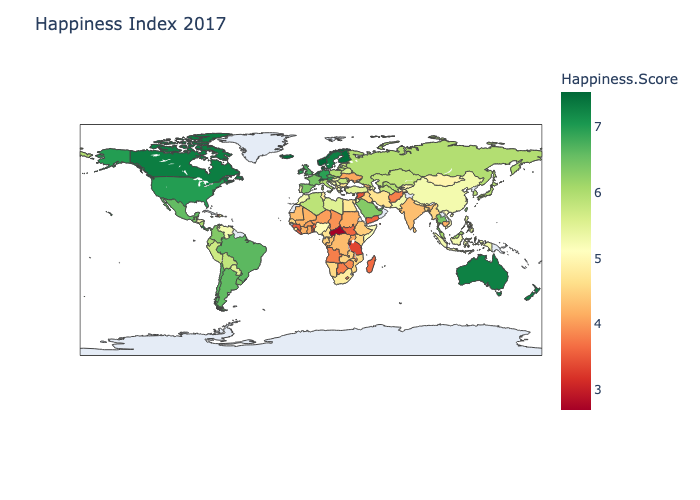

In [11]:
fig = px.choropleth(df,
                    locations='Country',
                    color='Happiness.Score',
                    locationmode='country names',
                    color_continuous_scale='RdYlGn')
fig.update_layout(title='Happiness Index 2017')
fig.show()

## 9. Стандартизація даних

Ознаки мають різні діапазони, тож перед кластеризацією приводимо їх до єдиного масштабу. Використовуємо функцію `data_scale()` з підтримкою трьох типів масштабування.

In [12]:
def data_scale(data, scaler_type='minmax'):
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.preprocessing import StandardScaler
    from sklearn.preprocessing import Normalizer
    if scaler_type == 'minmax':
        scaler = MinMaxScaler()
    if scaler_type == 'std':
        scaler = StandardScaler()
    if scaler_type == 'norm':
        scaler = Normalizer()

    scaler.fit(data)
    res = scaler.transform(data)
    return res


original_dataframe = df[features].copy()
data_scaled = data_scale(original_dataframe, scaler_type='std')
df_scaled = pd.DataFrame(data_scaled, columns=original_dataframe.columns)
print(df_scaled.head())

   Economy..GDP.per.Capita.    Family  Health..Life.Expectancy.   Freedom  \
0                  1.506188  1.203577                  1.038167  1.515836   
1                  1.186518  1.265036                  1.020812  1.452859   
2                  1.182345  1.472669                  1.194259  1.460590   
3                  1.383442  1.145561                  1.298272  1.413155   
4                  1.093985  1.227057                  1.091026  1.398978   

   Generosity  Trust..Government.Corruption.  
0    0.856964                       1.903084  
1    0.806856                       2.739998  
2    1.702013                       0.300066  
3    0.325028                       2.406809  
4   -0.010426                       2.560800  


## 10. Порівняння статистик до і після стандартизації

In [13]:
print('=== Оригінальні дані ===')
print(original_dataframe.describe().round(3))
print('\n=== Стандартизовані дані (StandardScaler) ===')
print(df_scaled.describe().round(3))

=== Оригінальні дані ===
       Economy..GDP.per.Capita.   Family  Health..Life.Expectancy.  Freedom  \
count                   155.000  155.000                   155.000  155.000   
mean                      0.985    1.189                     0.551    0.409   
std                       0.421    0.287                     0.237    0.150   
min                       0.000    0.000                     0.000    0.000   
25%                       0.663    1.043                     0.370    0.304   
50%                       1.065    1.254                     0.606    0.437   
75%                       1.318    1.414                     0.723    0.517   
max                       1.871    1.611                     0.949    0.658   

       Generosity  Trust..Government.Corruption.  
count     155.000                        155.000  
mean        0.247                          0.123  
std         0.135                          0.102  
min         0.000                          0.000  
25%     

**Висновок.** Після `StandardScaler` кожна ознака має **середнє ≈ 0 і стандартне відхилення ≈ 1**; діапазони значень усіх ознак стали співмірними. В оригінальних даних масштаби різнилися (наприклад, `Economy` до ~1.87, `Trust` до ~0.46), що надавало б непропорційну вагу «великим» ознакам у відстанях. Стандартизація усуває цей перекіс — тепер усі фактори роблять рівноцінний внесок у модель кластеризації.

## 11. Кластеризація моделлю гаусової суміші (GMM)

Перед побудовою фінальної моделі підбираємо кількість компонент за критеріями **BIC** (менше — краще) та **силуетом** (більше — краще).

In [14]:
X = df_scaled.values

print(f'{"k":>3}{"BIC":>12}{"Silhouette":>14}')
print('-' * 29)
for k in range(2, 8):
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42, n_init=5)
    labels = gmm.fit_predict(X)
    print(f'{k:>3}{gmm.bic(X):>12.1f}{silhouette_score(X, labels):>14.3f}')

  k         BIC    Silhouette
-----------------------------
  2      2289.9         0.251
  3      2334.2         0.273
  4      2419.4         0.215
  5      2464.6         0.220
  6      2547.0         0.190
  7      2510.7         0.174


In [15]:
# Фінальна модель: 3 кластери (найкращий силует, зрозуміла інтерпретація)
N_CLUSTERS = 3
gmm = GaussianMixture(n_components=N_CLUSTERS, covariance_type='full',
                      random_state=42, n_init=10)
df['Cluster'] = gmm.fit_predict(X)

# Впорядкуємо мітки кластерів за зростанням середнього щастя (для інтерпретованості)
order = df.groupby('Cluster')['Happiness.Score'].mean().sort_values().index
remap = {old: new for new, old in enumerate(order)}
df['Cluster'] = df['Cluster'].map(remap)

summary = df.groupby('Cluster').agg(
    n_countries=('Country', 'count'),
    happiness_mean=('Happiness.Score', 'mean'),
    gdp_mean=('Economy..GDP.per.Capita.', 'mean'),
    health_mean=('Health..Life.Expectancy.', 'mean'),
).round(3)
print('Кластери (0 = найменш щасливі, 2 = найщасливіші):')
print(summary)

Кластери (0 = найменш щасливі, 2 = найщасливіші):
         n_countries  happiness_mean  gdp_mean  health_mean
Cluster                                                    
0                 50           4.206     0.560        0.273
1                 79           5.579     1.074        0.650
2                 26           6.877     1.529        0.786


## 12. Теплова мапа розподілу країн за кластерами

/var/folders/vw/ty8wgr1n0237_dlxkbcl8rvh0000gn/T/ipykernel_10343/243833299.py:1: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(df,


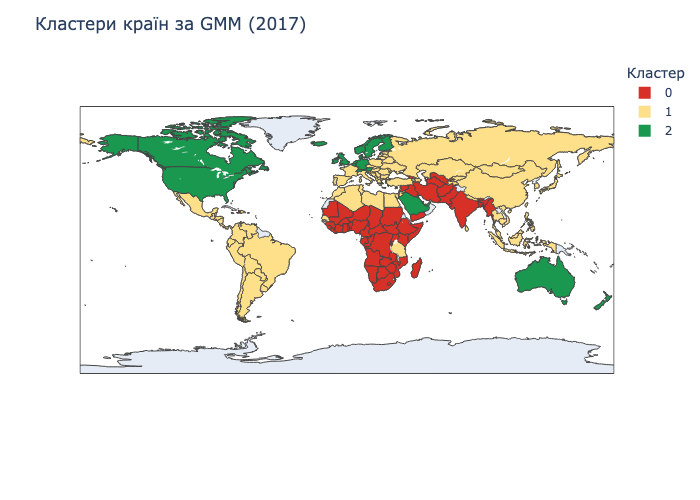

In [16]:
fig = px.choropleth(df,
                    locations='Country',
                    color=df['Cluster'].astype(str),
                    locationmode='country names',
                    category_orders={'color': ['0', '1', '2']},
                    color_discrete_sequence=['#d73027', '#fee08b', '#1a9850'],
                    labels={'color': 'Кластер'})
fig.update_layout(title='Кластери країн за GMM (2017)')
fig.show()

## 13. Вплив різних наборів ознак та ступеня стискання на кластеризацію

Проводимо обчислювальні експерименти: варіюємо (а) **набір ознак**, (б) **тип масштабування** та (в) **ступінь стискання** — кількість компонент GMM і тип матриці коваріації (`covariance_type` керує тим, наскільки «стиснуті»/гнучкі форми кластерів). Якість оцінюємо силуетом та узгодженістю з реальним рівнем щастя (ARI відносно поділу країн на 3 групи за квантилями Happiness.Score).

In [17]:
# Еталон: поділ країн на 3 групи за рівнем щастя
happiness_tertile = pd.qcut(df['Happiness.Score'], 3, labels=[0, 1, 2]).astype(int)

feature_sets = {
    'economy+health (2)': ['Economy..GDP.per.Capita.', 'Health..Life.Expectancy.'],
    'top-4 драйвери':     ['Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom'],
    'усі 6 факторів':      features,
}

print(f'{"Набір ознак":<22}{"scaler":>8}{"cov_type":>10}{"silhouette":>12}{"ARI":>8}')
print('-' * 60)
for fname, cols in feature_sets.items():
    for scaler_type in ['std', 'minmax']:
        for cov in ['full', 'diag', 'spherical']:
            Xf = data_scale(df[cols], scaler_type=scaler_type)
            g = GaussianMixture(n_components=3, covariance_type=cov,
                                random_state=42, n_init=5)
            lab = g.fit_predict(Xf)
            sil = silhouette_score(Xf, lab)
            ari = adjusted_rand_score(happiness_tertile, lab)
            print(f'{fname:<22}{scaler_type:>8}{cov:>10}{sil:>12.3f}{ari:>8.3f}')

Набір ознак             scaler  cov_type  silhouette     ARI
------------------------------------------------------------
economy+health (2)         std      full       0.456   0.311
economy+health (2)         std      diag       0.485   0.294
economy+health (2)         std spherical       0.495   0.331
economy+health (2)      minmax      full       0.466   0.311
economy+health (2)      minmax      diag       0.481   0.287
economy+health (2)      minmax spherical       0.496   0.299
top-4 драйвери             std      full       0.234   0.295
top-4 драйвери             std      diag       0.294   0.365
top-4 драйвери             std spherical       0.292   0.378
top-4 драйвери          minmax      full       0.273   0.371
top-4 драйвери          minmax      diag       0.312   0.365
top-4 драйвери          minmax spherical       0.308   0.355
усі 6 факторів             std      full       0.273   0.363
усі 6 факторів             std      diag       0.289   0.330
усі 6 факторів          

## 14. Загальний висновок

**Про модель.** Гаусова суміш (`GaussianMixture`) успішно згрупувала країни у **3 кластери**, які чітко відповідають рівню життя: «найменш щасливі» (переважно країни Африки та Південної Азії), «середні» (Східна Європа, Латинська Америка, частина Азії) та «найщасливіші» (Західна Європа, Північна Америка, Австралія). Середній рівень щастя монотонно зростає від кластера 0 до кластера 2 — тобто **кластеризація за факторами-драйверами відтворює реальний розподіл країн за щастям**, хоча модель жодного разу не «бачила» саму цільову ознаку.

**Про підготовку даних.** Стандартизація виявилася обов'язковою: без неї ознаки з більшим масштабом (`Economy`) домінували б у відстанях. Аналіз розподілів показав відхилення від нормальності та асиметрію, а кореляційний аналіз — сильний зв'язок щастя з економікою та здоров'ям і фактичну відсутність зв'язку зі щедрістю.

**Про експерименти з різними наборами ознак і ступенями стискання** (див. таблицю вище).
- **Набір ознак.** Найвищий **силует** (~0.49) дають лише 2 сильноскорельовані ознаки (economy+health) — вони формують найкомпактніші, добре відокремлені кластери, але огрублюють картину. Найкращу **узгодженість із реальним рівнем щастя** (ARI≈0.38) дає набір **top-4 драйверів**. Повний набір із 6 факторів має близький, але дещо нижчий ARI: додавання слабоінформативних ознак (`Generosity`, `Trust`) не покращує, а трохи «розмиває» узгодженість. Тобто більше ознак ≠ краща кластеризація.
- **Тип масштабування.** `std` та `minmax` дають дуже близькі результати; істотної переваги жодного немає — головне, що масштабування взагалі застосоване.
- **Ступінь стискання (`covariance_type`).** Це параметр, що керує «стисненістю» форми гаусіан: `spherical` (сфери) — найсильніше стискання, `diag` — проміжне, `full` (довільні еліпсоїди) — найменше. На цьому невеликому наборі (155 країн) простіші `spherical`/`diag` часто дають **не гірший, а подекуди й вищий** силует та ARI, ніж `full`: гнучка `full`-модель має більше параметрів і схильна переналаштовуватися на малих даних. Оптимальна кількість компонент за BIC і силуетом — близько **3**, що збігається з інтуїтивним поділом на бідні/середні/багаті країни.

**Підсумок.** Модель суміші гаусіан у поєднанні з коректною підготовкою даних (стандартизація + обґрунтований відбір ознак) дає інтерпретовані кластери, що добре відповідають оригінальному розподілу країн за рівнем щастя.